In [13]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

In [14]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [15]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [16]:
import numpy as np

In [17]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [19]:
from sagemaker.tuner import HyperparameterTuner
#Solo variables importantes
nombre_exportado = HyperparameterTuner.attach('hpo-plaft-pj-minoris-260602-2012').best_training_job()
print(nombre_exportado)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
hpo-plaft-pj-minoris-260602-2012-044-9ae0082d


In [7]:
!pip install xgboost --prefer-binary

In [8]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
bucket_name = 'ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'
nombre_exportado = 'model'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/calibrado_v1/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/tmp/ipykernel_5518/3721980399.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='model')


In [9]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
train_path        = f"{base_s3_path}/train_total.csv"
val_path          = f"{base_s3_path}/validation_total.csv"
test_path         = f"{base_s3_path}/test_total.csv"
extras_val_path   = f"{base_s3_path}/extras_validation_total.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_train = pd.read_csv(train_path, header=None, names=column_order)
df_val   = pd.read_csv(val_path,   header=None, names=column_order)
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Train : {df_train.shape}")
print(f"  Val   : {df_val.shape}")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_val  = pd.read_csv(extras_val_path)
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_val  = pd.concat([df_val.reset_index(drop=True), 
                     extras_val[['key_value','cod_cli' ,'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['key_value','cod_cli' , 'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_val  ahora tiene {df_val.shape[1]} columnas (incluye num_documento y mes_base)")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_val[['key_value', 'cod_cli' ,'cod_mes', 'target','tipo_alerta_n2','trx_riesgo_cliente']].head())

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Se cargaron 37 variables desde S3
Primeras 10 variables: ['target', 'mto_pas_soles', 'imp_trx_abonosefect_6m', 'imp_trx_cargosefe_6m', 'avg_trx_cargostot_3m', 'cnt_trx_cargostot_3m', 'cnt_trx_abonospromtot_3m', 'rat_trx_abonosefectot_1m', 'rat_trx_abonosefectot_3m', 'rat_trx_abonosefectot_9m']

Shapes cargados desde S3:
  Train : (117250, 37)
  Val   : (57750, 37)
  Test  : (1509824, 37)

Listo! Todo cargado correctamente desde S3
df_val  ahora tiene 42 columnas (incluye num_documento y mes_base)
df_test ahora tiene 42 columnas


,key_value,cod_cli,cod_mes,target,tipo_alerta_n2,trx_riesgo_cliente
0,B187D835B1222A4CAACF328414AA8D4D6BCE51521909E1...,17182072.0,202506.0,0.0,0,SIN_INFO
1,E347EB83A91F30F1F42E9BF014BD326166AE369578EBDF...,10212088.0,202507.0,0.0,0,SIN_INFO
2,A720AA6CAC7DC6F6C168D89C21B51ECAB0B45A203E15A6...,21013610.0,202503.0,0.0,0,SIN_INFO
3,A7FD8F5E91595384718B143EA0B5322ACEA1C9597DBB53...,19976264.0,202501.0,0.0,0,SIN_INFO
4,9446D8BCA004E0B0497572CED2727C73BC17716D68AFFC...,20984592.0,202506.0,0.0,0,SIN_INFO


In [34]:
df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [10]:
df_test_1= df_test[(df_test.tipo_alerta_n2 !='0')]

In [11]:
df_test_0426= df_test[(df_test.cod_mes ==202604)]

In [12]:
# Guardar parquet en S3
df_test_0426.to_parquet(
    's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PJ/MINORISTA/DATA_INFERENCIA_PILOTO/202604.parquet',
    index=False
)

In [38]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test_1.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [39]:
df_test_3['prob'] = model.predict(dtest)

In [74]:
# Guardar parquet en S3
df_test_0426.to_parquet(
    's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PJ/MINORISTA/DATA_INFERENCIA_PILOTO/base_conscore_202604.parquet',
    index=False
)

In [40]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508.0    0.492647
202509.0    0.620713
202510.0    0.644635
202511.0    0.399537
202512.0    0.713768
202601.0    0.359167
202602.0    0.667117
202603.0    0.340517
202604.0    0.489736
dtype: float64


/tmp/ipykernel_32177/29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [41]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: 0.5253


In [19]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_val_1 = df_val.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_val_1.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [20]:
df_test.target.value_counts()

target
0.0    1508768
1.0       1056
Name: count, dtype: int64

In [21]:
407/809

0.5030902348578492

In [22]:
df_test.tipo_alerta_n2.value_counts()

tipo_alerta_n2
0                  1503443
AUTOMATICA            4653
MANUAL                1208
SEMI AUTOMATICA        520
Name: count, dtype: int64

In [23]:
#df_test_1 = df_test[df_test['cod_mes'].between(202508, 202604)].copy()

In [32]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
#df_test_2 = df_test_1.copy()
#df_test_3= df_test_2[(df_test_2.tipo_alerta_n2 =='AUTOMATICA')&(df_test_2.trx_riesgo_cliente !='A')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli' ,'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [42]:
predictions = model.predict(dtest)
y_test = df_test_3.target.to_frame()
y_test['prob'] = predictions
y_test_1=y_test['target'].values
y_score=y_test['prob'].values
y_test['Rangos']=pd.qcut(y_test['prob'],10,duplicates='drop')
Tabla_Deciles(y_test['target'],y_test['prob'],n=5)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00179, 0.454]",445,8,0.017660,0.221393,1.000000,445,255
"(0.454, 0.725]",438,15,0.033113,0.439303,0.968627,883,247
"(0.725, 0.888]",418,35,0.077263,0.647264,0.909804,1301,232
"(0.888, 0.972]",396,57,0.125828,0.844279,0.772549,1697,197
"(0.972, 0.999]",313,140,0.309051,1.000000,0.549020,2010,140



Evaluando mes 202508
AUC 202508:  0.7463
Gini 202508: 49.26

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


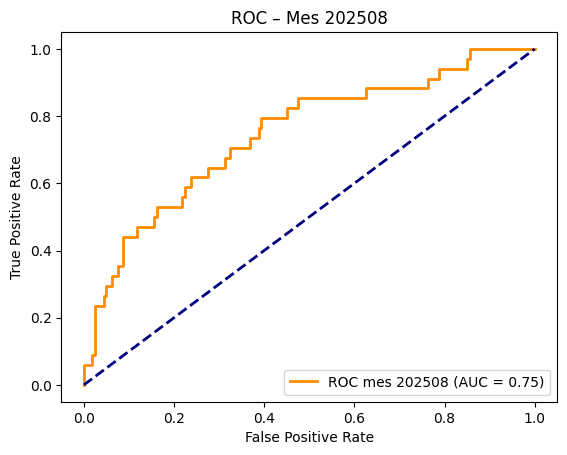


Evaluando mes 202509
AUC 202509:  0.8104
Gini 202509: 62.07

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


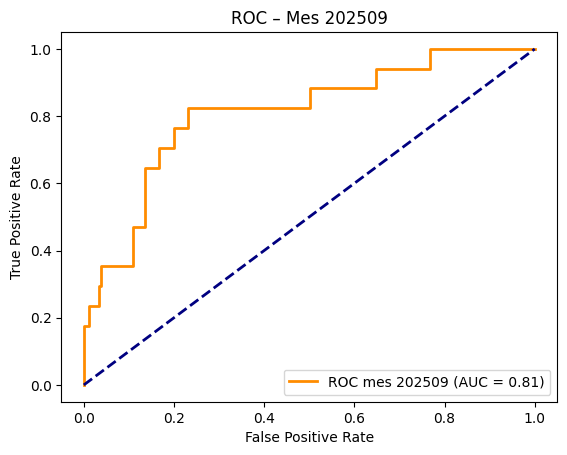


Evaluando mes 202510
AUC 202510:  0.8223
Gini 202510: 64.46

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


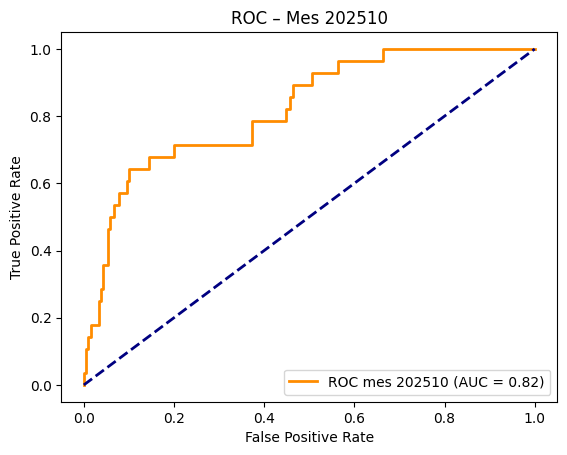


Evaluando mes 202511
AUC 202511:  0.6998
Gini 202511: 39.95

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


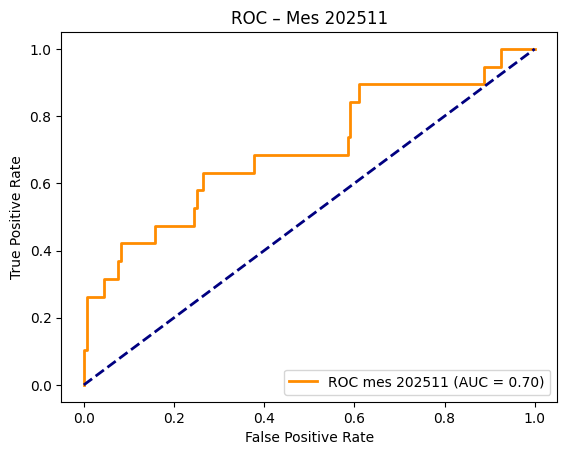


Evaluando mes 202512
AUC 202512:  0.8569
Gini 202512: 71.38

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


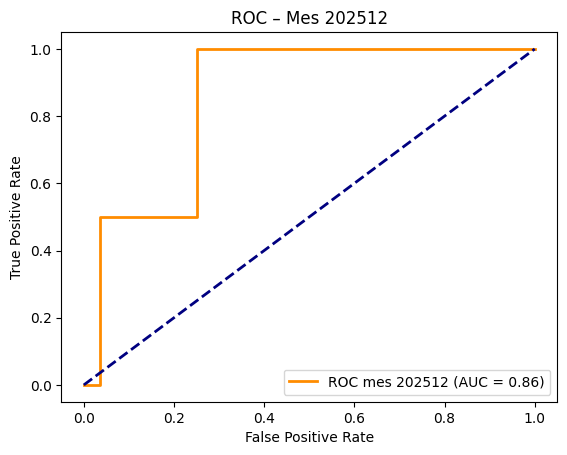


Evaluando mes 202601
AUC 202601:  0.6796
Gini 202601: 35.92

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


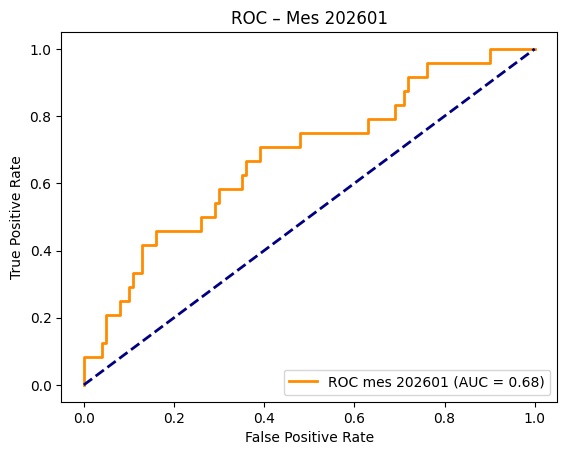


Evaluando mes 202602
AUC 202602:  0.8336
Gini 202602: 66.71

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


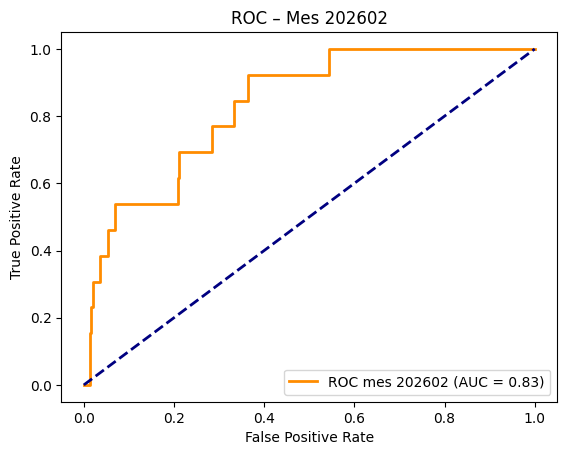


Evaluando mes 202603
AUC 202603:  0.6703
Gini 202603: 34.05

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


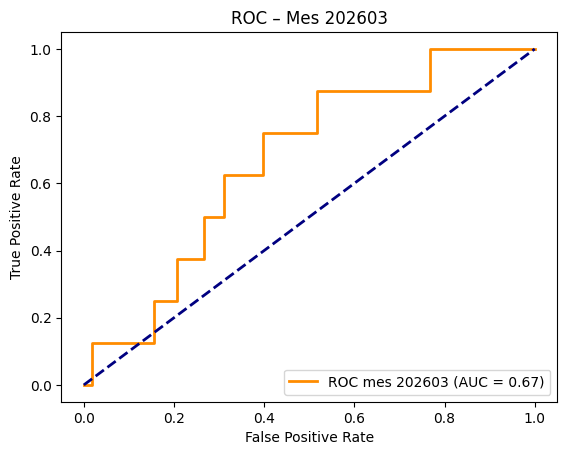


Evaluando mes 202604
AUC 202604:  0.7449
Gini 202604: 48.97

Deciles – Total

Deciles – Solo alertas (10)

Deciles – Solo alertas (5)


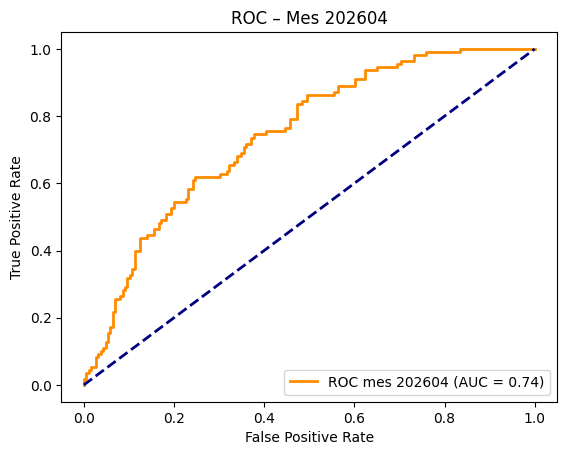

In [44]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

cols_excluir = ['key_value', 'cod_mes',  'cod_cli' ,'tipo_alerta_n2', 'target','trx_riesgo_cliente']

meses_eval = [202508, 202509, 202510, 202511,202512,202601,202602,202603,202604]

resultados_auc = {}
resultados_gini = {}
resultados_deciles = {}

for mes in meses_eval:
    print(f"\n==============================")
    print(f"Evaluando mes {mes}")
    print(f"==============================")

    # -------------------------------------------------
    # 1. Filtrar data del mes
    # -------------------------------------------------
    
    test_data = df_test_1[df_test_1.cod_mes == float(mes)].copy()

    if test_data.empty:
        print(f"⚠️ No hay datos para el mes {mes}")
        continue

    # -------------------------------------------------
    # 2. Preparar X_test
    # -------------------------------------------------
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')

    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    # -------------------------------------------------
    # 3. Predicciones
    # -------------------------------------------------
    predictions = model.predict(dtest)
    test_data['prob'] = predictions

    # -------------------------------------------------
    # 4. Métricas ROC / AUC / Gini
    # -------------------------------------------------
    y_true = test_data['target'].values
    y_score = test_data['prob'].values

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    gini = (roc_auc * 2 - 1) * 100

    resultados_auc[mes] = roc_auc
    resultados_gini[mes] = gini

    print(f"AUC {mes}:  {roc_auc:.4f}")
    print(f"Gini {mes}: {gini:.2f}")

    # -------------------------------------------------
    # 5. Deciles – población total
    # -------------------------------------------------
    test_data['Rangos'] = pd.qcut(
        test_data['prob'],
        10,
        duplicates='drop'
    )

    print("\nDeciles – Total")
    Tabla_Deciles(
        test_data['target'],
        test_data['prob'],
        n=10
    )

    # -------------------------------------------------
    # 6. Deciles – solo alertas
    # -------------------------------------------------
    test_data_alerta = test_data[test_data.tipo_alerta_n2 != 0].copy()

    if not test_data_alerta.empty:
        test_data_alerta['Rangos'] = pd.qcut(
            test_data_alerta['prob'],
            10,
            duplicates='drop'
        )

        print("\nDeciles – Solo alertas (10)")
        Tabla_Deciles(
            test_data_alerta['target'],
            test_data_alerta['prob'],
            n=10
        )

        print("\nDeciles – Solo alertas (5)")
        Tabla_Deciles(
            test_data_alerta['target'],
            test_data_alerta['prob'],
            n=5
        )

    # -------------------------------------------------
    # 7. ROC Curve (opcional por mes)
    # -------------------------------------------------
    plt.figure()
    plt.plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"ROC mes {mes} (AUC = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC – Mes {mes}")
    plt.legend(loc="lower right")
    plt.show()

In [46]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# -------------------------------------------------
# Configuración
# -------------------------------------------------
MES = 202508
THRESHOLD = 0.99296  # tu umbral definido
cols_excluir = ['key_value', 'cod_cli' ,'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']

# -------------------------------------------------
# Filtrar datos del mes
# -------------------------------------------------
test_data = df_test_1[df_test_1.cod_mes == float(MES)].copy()

if test_data.empty:
    print(f"⚠️ No hay datos para el mes {MES}")
else:
    # Preparar X_test
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    # Predicciones
    test_data['prob'] = model.predict(dtest)

    # Verdaderos / predichos
    y_true = test_data['target'].values
    y_score = test_data['prob'].values
    y_pred = (y_score >= THRESHOLD).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n=== Matriz de Confusión Mes {MES} ===")
    print(pd.DataFrame(
        cm,
        index=["Real 0", "Real 1"],
        columns=["Pred 0", "Pred 1"]
    ))
    print(f"\nTP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
    print(f"Precision: {tp / (tp + fp):.4f}")
    print(f"Recall:    {tp / (tp + fn):.4f}")



=== Matriz de Confusión Mes 202508 ===
        Pred 0  Pred 1
Real 0     152       8
Real 1      24      10

TP: 10 | FP: 8 | FN: 24 | TN: 152
Precision: 0.5556
Recall:    0.2941


In [47]:
resumen = pd.DataFrame({
    'cod_mes': resultados_auc.keys(),
    'auc': resultados_auc.values(),
    'gini': resultados_gini.values()
}).sort_values('cod_mes')

print("\nResumen desempeño por mes")
print(resumen)


Resumen desempeño por mes
   cod_mes       auc       gini
0   202508  0.746324  49.264706
1   202509  0.810357  62.071315
2   202510  0.822318  64.463545
3   202511  0.699768  39.953658
4   202512  0.856884  71.376812
5   202601  0.679583  35.916667
6   202602  0.833558  66.711651
7   202603  0.670259  34.051724
8   202604  0.744868  48.973607


In [48]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [49]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')]

In [50]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test_1[df_test_1.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [51]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.009899999999999999, 0.405]",36,3,0.076923,0.22500,1.000000,36,34
"(0.405, 0.698]",37,2,0.051282,0.45625,0.911765,73,31
"(0.698, 0.862]",33,5,0.131579,0.66250,0.852941,106,29
"(0.862, 0.964]",31,8,0.205128,0.85625,0.705882,137,24
"(0.964, 0.997]",23,16,0.410256,1.00000,0.470588,160,16


In [52]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0392, 0.501]",56,0,0.000000,0.216216,1.000000,56,17
"(0.501, 0.748]",53,2,0.036364,0.420849,1.000000,109,17
"(0.748, 0.9]",54,1,0.018182,0.629344,0.882353,163,15
"(0.9, 0.972]",53,2,0.036364,0.833977,0.823529,216,14
"(0.972, 0.998]",43,12,0.218182,1.000000,0.705882,259,12


In [53]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00179, 0.371]",54,0,0.000000,0.224066,1.000000,54,28
"(0.371, 0.678]",52,2,0.037037,0.439834,1.000000,106,28
"(0.678, 0.892]",47,6,0.113208,0.634855,0.928571,153,26
"(0.892, 0.981]",53,1,0.018519,0.854772,0.714286,206,20
"(0.981, 0.999]",35,19,0.351852,1.000000,0.678571,241,19


In [54]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.021599999999999998, 0.442]",34,2,0.055556,0.213836,1.000000,34,19
"(0.442, 0.649]",32,3,0.085714,0.415094,0.894737,66,17
"(0.649, 0.893]",34,2,0.055556,0.628931,0.736842,100,14
"(0.893, 0.972]",32,3,0.085714,0.830189,0.631579,132,12
"(0.972, 0.998]",27,9,0.250000,1.000000,0.473684,159,9


In [55]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0131, 0.397]",56,0,0.000000,0.202899,1.0,56,2
"(0.397, 0.629]",55,0,0.000000,0.402174,1.0,111,2
"(0.629, 0.766]",56,0,0.000000,0.605072,1.0,167,2
"(0.766, 0.923]",54,1,0.018182,0.800725,1.0,221,2
"(0.923, 0.997]",55,1,0.017857,1.000000,0.5,276,1


In [56]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0131, 0.322]",25,0,0.000000,0.215517,1.000,25,8
"(0.322, 0.584]",24,1,0.040000,0.422414,1.000,49,8
"(0.584, 0.86]",22,2,0.083333,0.612069,0.875,71,7
"(0.86, 0.983]",22,3,0.120000,0.801724,0.625,93,5
"(0.983, 0.998]",23,2,0.080000,1.000000,0.250,116,2


In [57]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.009899999999999999, 0.77]",55,5,0.083333,0.295699,1.000000,55,110
"(0.77, 0.904]",43,16,0.271186,0.526882,0.954545,98,105
"(0.904, 0.958]",38,21,0.355932,0.731183,0.809091,136,89
"(0.958, 0.986]",29,30,0.508475,0.887097,0.618182,165,68
"(0.986, 0.999]",21,38,0.644068,1.000000,0.345455,186,38


In [58]:
df_test_2= df_test_1[(df_test_1.cod_mes ==202604)]

In [59]:
df_test_2.head()

,target,mto_pas_soles,imp_trx_abonosefect_6m,imp_trx_cargosefe_6m,avg_trx_cargostot_3m,cnt_trx_cargostot_3m,cnt_trx_abonospromtot_3m,rat_trx_abonosefectot_1m,rat_trx_abonosefectot_3m,rat_trx_abonosefectot_9m,...,ros_por_trx_3m,ingresos_vs_facturacion,pasivo_vs_ingresos,ratio_egresos_exterior,ratio_ingresos_exterior,key_value,cod_cli,cod_mes,tipo_alerta_n2,trx_riesgo_cliente
1037,1.0,2.398132e+06,675.00,0.0,0.0,183.0,12.00,0.0,0.00,0.0270,...,0.0,0.00000,0.027710,0.028088,0.999985,28ECDB96F778F1F262D5F758C342255DCA97D57B94ADFE...,21781748.0,202604.0,AUTOMATICA,M
10997,1.0,5.259657e+04,0.00,0.0,0.0,82.0,8.00,0.0,0.00,0.0000,...,0.0,0.00000,0.017199,0.000000,0.000000,627911C6049E30C3C13E37FDC707444E285158C3599B0A...,18001166.0,202604.0,AUTOMATICA,M
11496,1.0,6.293140e+03,0.00,954921.7,3.0,282.0,13.67,0.0,0.00,0.0101,...,0.0,0.00000,0.002176,0.000000,0.000000,F73B9C74D84E32CD22E6D5867F4C144A1728030FB643BA...,19980536.0,202604.0,AUTOMATICA,M
22289,0.0,4.254891e+06,965.91,0.0,0.0,320.0,37.00,0.0,0.00,0.0048,...,0.0,5.96815,0.021433,0.000093,0.000019,80DD92D1E5BF8386B05FD12E5686DBCD1D6C5E36CB8B3B...,13176854.0,202604.0,AUTOMATICA,M
24416,1.0,1.884132e+02,137.04,0.0,0.0,43.0,2.67,0.0,0.25,0.2500,...,0.0,0.00000,0.000012,0.000000,0.999991,334D97745CFB917890A8134894CB6FC42B707840A88826...,22021328.0,202604.0,AUTOMATICA,M


In [60]:
meses = [202508, 202509, 202510, 202511, 202512, 202601, 202602, 202603, 202604]

tablas_quintiles = {}

for mes in meses:

    test_data = df_test_1[df_test_1.cod_mes == float(mes)].copy()

    # Predicción
    cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'trx_riesgo_cliente']
    
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')

    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

    # =====================================================
    # GUARDAR SOLO PARA 202604
    # =====================================================
    if mes == 202604:

        salida_202604 = test_data_alerta[
            [
                'target',
                'key_value',
                'cod_mes',
                'tipo_alerta_n2',
                'trx_riesgo_cliente',
                'prob'
            ]
        ].copy()

        # Renombrar prob -> score
        salida_202604 = salida_202604.rename(
            columns={'prob': 'score'}
        )

        # Crear grupos/quintiles del score
        salida_202604['grupo_score'] = pd.qcut(
            salida_202604['score'],
            q=5,
            labels=[1, 2, 3, 4, 5],
            duplicates='drop'
        )

        # Guardar CSV
        salida_202604.to_csv(
            'score_202604.csv',
            index=False
        )

        print("Archivo score_202604.csv generado correctamente")

Archivo score_202604.csv generado correctamente


In [61]:
tabla_grupos = salida_202604.groupby('grupo_score').agg(
    min_score=('score', 'min'),
    max_score=('score', 'max'),
    cantidad=('score', 'count'),
    target_1=('target', 'sum'),
    target_rate=('target', 'mean')
).reset_index()

tabla_grupos['target_rate'] = (
    tabla_grupos['target_rate'] * 100
).round(2)

print(tabla_grupos)

  grupo_score  min_score  max_score  cantidad  target_1  target_rate
0           1   0.010862   0.769845        60       5.0         8.33
1           2   0.773592   0.904404        59      16.0        27.12
2           3   0.906180   0.958285        59      21.0        35.59
3           4   0.958671   0.985811        59      30.0        50.85
4           5   0.986408   0.998816        59      38.0        64.41


/tmp/ipykernel_32177/2571084096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_grupos = salida_202604.groupby('grupo_score').agg(


In [62]:
salida_202604['grupo_score'] = pd.qcut(
    salida_202604['score'],
    q=5,
    labels=['P1', 'P2', 'P3', 'P4', 'P5'],
    duplicates='drop'
)

In [63]:
# Crear grupos P1-P5
salida_202604['grupo_score'] = pd.qcut(
    salida_202604['score'],
    q=5,
    labels=['P1', 'P2', 'P3', 'P4', 'P5'],
    duplicates='drop'
)

# Volver a guardar el dataset final
salida_202604.to_csv(
    'score_202604.csv',
    index=False
)

print("Archivo actualizado score_202604.csv guardado correctamente")

Archivo actualizado score_202604.csv guardado correctamente


In [64]:
tabla_grupos = salida_202604.groupby('grupo_score').agg(
    min_score=('score', 'min'),
    max_score=('score', 'max'),
    cantidad=('score', 'count'),
    target_1=('target', 'sum'),
    target_rate=('target', 'mean')
).reset_index()

tabla_grupos['target_rate'] = (
    tabla_grupos['target_rate'] * 100
).round(2)

print(tabla_grupos)

  grupo_score  min_score  max_score  cantidad  target_1  target_rate
0          P1   0.010862   0.769845        60       5.0         8.33
1          P2   0.773592   0.904404        59      16.0        27.12
2          P3   0.906180   0.958285        59      21.0        35.59
3          P4   0.958671   0.985811        59      30.0        50.85
4          P5   0.986408   0.998816        59      38.0        64.41


/tmp/ipykernel_32177/2571084096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_grupos = salida_202604.groupby('grupo_score').agg(


In [65]:
#from pathlib import Path
#output_path = Path(r"/PLAFT/Desarrollo/Desarrollo/PJ/MINORISTA/Artefactos/Inferencia/alertas_ordenadas_automaticas_sinriegoalto.csv")
#df_test_2.to_csv(output_path, index=False, encoding="utf-8-sig")
#print(f"✓ CSV exportado: {output_path} | Filas: {len(df_test_2):,}")

In [66]:
meses = [202508, 202509, 202510, 202511,202512]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=1000
    )


In [67]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00036837999999999997, 0.0016393]",162,0,0.000000,0.001004,1.000000,162,120
"(0.0016393, 0.0021438]",161,0,0.000000,0.002003,1.000000,323,120
"(0.0021438, 0.0026791]",162,0,0.000000,0.003007,1.000000,485,120
"(0.0026791, 0.0029473]",161,0,0.000000,0.004005,1.000000,646,120
"(0.0029473, 0.0031477]",162,0,0.000000,0.005009,1.000000,808,120
...,...,...,...,...,...,...,...
"(0.98216, 0.98667]",157,5,0.030864,0.996324,0.483333,160702,58
"(0.98667, 0.99057]",152,9,0.055901,0.997266,0.441667,160854,53
"(0.99057, 0.99324]",157,5,0.030864,0.998239,0.366667,161011,44


In [68]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00043109999999999996, 0.001702]",163,0,0.000000,0.001002,1.000000,163,97
"(0.001702, 0.002206]",163,0,0.000000,0.002003,1.000000,326,97
"(0.002206, 0.00266]",163,0,0.000000,0.003005,1.000000,489,97
"(0.00266, 0.002981]",167,0,0.000000,0.004031,1.000000,656,97
"(0.002981, 0.003195]",177,0,0.000000,0.005119,1.000000,833,97
...,...,...,...,...,...,...,...
"(0.9828, 0.987]",158,5,0.030675,0.996141,0.298969,162113,29
"(0.987, 0.9906]",162,1,0.006135,0.997137,0.247423,162275,24
"(0.9906, 0.9931]",160,3,0.018405,0.998120,0.237113,162435,23


In [69]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00043109999999999996, 0.001687]",165,0,0.000000,0.001002,1.000000,165,122
"(0.001687, 0.002202]",165,0,0.000000,0.002004,1.000000,330,122
"(0.002202, 0.002682]",165,0,0.000000,0.003006,1.000000,495,122
"(0.002682, 0.002943]",169,0,0.000000,0.004033,1.000000,664,122
"(0.002943, 0.003144]",160,0,0.000000,0.005004,1.000000,824,122
...,...,...,...,...,...,...,...
"(0.9832, 0.9872]",160,4,0.024390,0.996247,0.377049,164034,46
"(0.9872, 0.991]",161,4,0.024242,0.997224,0.344262,164195,42
"(0.991, 0.9937]",161,4,0.024242,0.998202,0.311475,164356,38


In [70]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0004980799999999999, 0.0017159]",172,0,0.000000,0.001035,1.000000,172,66
"(0.0017159, 0.0021973]",161,0,0.000000,0.002003,1.000000,333,66
"(0.0021973, 0.002701]",166,0,0.000000,0.003001,1.000000,499,66
"(0.002701, 0.0029812]",174,0,0.000000,0.004048,1.000000,673,66
"(0.0029812, 0.0031712]",161,0,0.000000,0.005017,1.000000,834,66
...,...,...,...,...,...,...,...
"(0.98486, 0.98814]",164,2,0.012048,0.996096,0.287879,165602,19
"(0.98814, 0.9913]",166,1,0.005988,0.997095,0.257576,165768,17
"(0.9913, 0.99362]",163,3,0.018072,0.998075,0.242424,165931,16


In [71]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00036636, 0.0017159]",177,0,0.000000,0.001033,1.0000,177,16
"(0.0017159, 0.0022683]",166,0,0.000000,0.002002,1.0000,343,16
"(0.0022683, 0.0027595]",175,0,0.000000,0.003024,1.0000,518,16
"(0.0027595, 0.0030288]",177,0,0.000000,0.004057,1.0000,695,16
"(0.0030288, 0.003195]",162,0,0.000000,0.005002,1.0000,857,16
...,...,...,...,...,...,...,...
"(0.98516, 0.98858]",171,0,0.000000,0.996019,0.2500,170633,4
"(0.98858, 0.99154]",171,1,0.005814,0.997017,0.2500,170804,4
"(0.99154, 0.99401]",170,1,0.005848,0.998010,0.1875,170974,3


In [72]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)


In [73]:
meses = [202508, 202509, 202510, 202511, 202512,202604]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    cols_excluir = ['key_value', 'cod_mes',  'cod_cli' ,'tipo_alerta_n2', 'target','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')

    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    test_data['prob'] = model.predict(dtest)

    # Solo alertas nuevas
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k


In [74]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.996268,18.0,0.150000,0.1800,202508
1,200,0.994987,32.0,0.266667,0.1600,202508
2,500,0.990223,45.0,0.375000,0.0900,202508
3,1000,0.976493,64.0,0.533333,0.0640,202508
4,2000,0.940890,75.0,0.625000,0.0375,202508
5,100,0.996556,9.0,0.092784,0.0900,202509
6,200,0.994947,15.0,0.154639,0.0750,202509
7,500,0.990508,23.0,0.237113,0.0460,202509
8,1000,0.977430,35.0,0.360825,0.0350,202509
9,2000,0.941859,50.0,0.515464,0.0250,202509


In [75]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [76]:
resultados_mes = {}

for mes in meses:
    df_mes = df_test[df_test.cod_mes == mes].copy()
    df_mes = df_mes[df_mes.tipo_alerta_n2 != 0]

    if df_mes.empty:
        continue

    X = df_mes.drop(
        columns=["key_value", "cod_mes", 'cod_cli' , "tipo_alerta_n2", "target","trx_riesgo_cliente"],
        errors="ignore"
    )

    dtest = xgb.DMatrix(X)
    df_mes["prob"] = model.predict(dtest)

    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target",
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla



In [77]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))



Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.994987,0.16,0.266667,0.2



Mes 202509


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.994947,0.075,0.154639,0.10101



Mes 202510


...

,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.995466,0.055,0.166667,0.082707



Mes 202512


,grupo,casos_hasta,threshold,precision,recall,f1
3,4,800,0.986214,0.005,0.25,0.009804



Mes 202604


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.99053,0.12,0.306383,0.172455


In [78]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos


,grupo,casos_hasta,threshold,precision,recall,f1,mes
0,1.0,200.0,0.994987,0.160,0.266667,0.200000,202508.0
0,1.0,200.0,0.994947,0.075,0.154639,0.101010,202509.0
0,1.0,200.0,0.995217,0.130,0.213115,0.161491,202510.0
0,1.0,200.0,0.995466,0.055,0.166667,0.082707,202511.0
3,4.0,800.0,0.986214,0.005,0.250000,0.009804,202512.0
2,3.0,600.0,0.990530,0.120,0.306383,0.172455,202604.0


In [79]:
threshold_final = df_optimos["threshold"].quantile(0.25)
threshold_final


0.9916345477104187

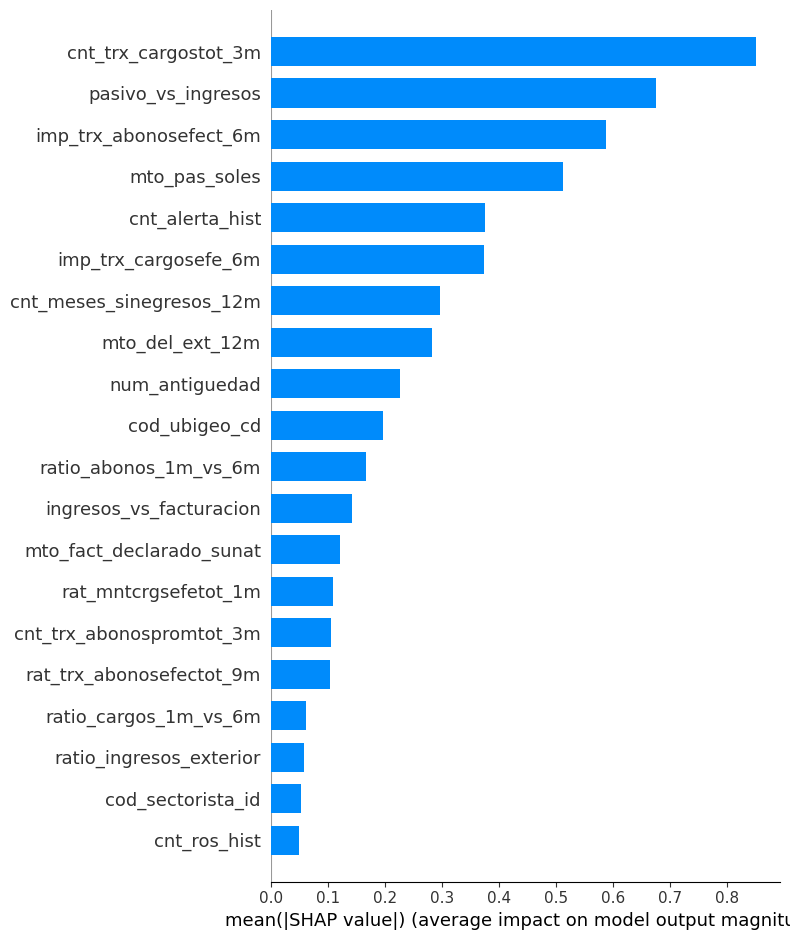

In [80]:
import shap
import pandas as pd
import numpy as np

# ===============================
# Dataset de referencia (ej: 202508)
# ===============================
df_ref = df_test[
    (df_test.cod_mes == 202508) 
    #&(df_test.tipo_alerta_n2 != '0')
].copy()

cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']
X_ref = df_ref.drop(columns=cols_excluir, errors='ignore')

# SHAP explainer (XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ref)

# Summary plot
shap.summary_plot(shap_values, X_ref, plot_type="bar")


In [81]:
variable_names = X_test.columns
# Calcula la magnitud promedio de los valores SHAP para cada variable
average_shap_values = np.abs(shap_values).mean(axis=0)

# Crea una lista de tuplas (variable, importancia, valor_absoluto)
variable_importance = [(variable_name, importance, abs_value) for variable_name, importance, abs_value in zip(variable_names, average_shap_values, shap_values.mean(axis=0))]

# Ordena la lista de importancia de mayor a menor
variable_importance.sort(key=lambda x: x[1], reverse=True)

# Obtén las variables más importantes junto con sus importancias y valores absolutos
variables_mas_importantes = [(variable[0], variable[1], variable[2]) for variable in variable_importance]

In [82]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    
    # Define el escritor CSV
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])


In [83]:
variables_mas_importantes

[('cnt_trx_cargostot_3m', 0.84954464, -0.6576742),
 ('pasivo_vs_ingresos', 0.6752937, -0.30622083),
 ('imp_trx_abonosefect_6m', 0.5880823, -0.5217137),
 ('mto_pas_soles', 0.51245654, -0.33255488),
 ('cnt_alerta_hist', 0.37628293, -0.2705419),
 ('imp_trx_cargosefe_6m', 0.3742682, -0.29509637),
 ('cnt_meses_sinegresos_12m', 0.2957895, -0.18884629),
 ('mto_del_ext_12m', 0.28280842, -0.26713395),
 ('num_antiguedad', 0.22718386, -0.14715362),
 ('cod_ubigeo_cd', 0.19770133, -0.112318315),
 ('ratio_abonos_1m_vs_6m', 0.1663171, -0.07697514),
 ('ingresos_vs_facturacion', 0.14319423, -0.049053382),
 ('mto_fact_declarado_sunat', 0.12236159, -0.08837337),
 ('rat_mntcrgsefetot_1m', 0.110102475, -0.021963835),
 ('cnt_trx_abonospromtot_3m', 0.10551917, -0.07989653),
 ('rat_trx_abonosefectot_9m', 0.10464878, -0.07758664),
 ('ratio_cargos_1m_vs_6m', 0.061692644, -0.047432944),
 ('ratio_ingresos_exterior', 0.05773753, -0.049462907),
 ('cod_sectorista_id', 0.054073323, -0.045607936),
 ('cnt_ros_hist', 0.

In [84]:
import shap
import pandas as pd
import numpy as np

# ===============================
# Dataset de referencia (ej: 202508)
# ===============================
df_ref = df_test[
    (df_test.mes_base == 202508) &
    (df_test.tipo_alerta_n2 != '0')
].copy()

cols_excluir = ['num_documento', 'mes_base', 'tipo_alerta_n2', 'target']
X_ref = df_ref.drop(columns=cols_excluir, errors='ignore')
y_ref = df_ref['target']

# ===============================
# SHAP explainer (XGBoost)
# ===============================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ref)  # shape: (n_samples, n_features)

# Convertir a DataFrame
shap_df = pd.DataFrame(shap_values, columns=X_ref.columns)

# ===============================
# 1️⃣ Magnitud promedio por variable
# ===============================
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# ===============================
# 2️⃣ Dirección: promedio SHAP correlacionado con target
# ===============================
mean_shap = shap_df.mean()  # promedio SHAP por variable
corr_shap_target = pd.Series({col: np.corrcoef(shap_df[col], y_ref)[0,1] for col in X_ref.columns})

# ===============================
# 3️⃣ Resultado final
# ===============================
shap_summary = pd.DataFrame({
    'Variable': X_ref.columns,
    'Importancia_SHAP': mean_abs_shap.values,
    'Promedio_SHAP': mean_shap.values,
    'Correlacion_SHAP_Target': corr_shap_target.values,
    'Direccion': np.where(mean_shap > 0, 'Directa', 'Inversa')
}).sort_values(by='Importancia_SHAP', ascending=False)

# ===============================
# Mostrar top 20
# ===============================
print(shap_summary.head(20))


AttributeError: 'DataFrame' object has no attribute 'mes_base'

In [ ]:
shap_summary.head(69)